# <span style="color:green"> Numerical Simulation Laboratory (NSL)
#### Emma Franco
## <span style="color:blue">  Lecture 3</span>
### <span style= "color: black" > Es03.1

In questo esercizio l'obiettivo è stimare a $t=0$ il prezzo di un'opzione *call* europea (*vanilla*), $C[S(0),0]$, ed il prezzo di una opzione *put* europea, $P[S(0),0]$ usando tecniche Monte Carlo. 

In particolare:
1. verrà campionato **direttamente** il prezzo finale dell’asset $S(T)$ per un processo $GBM(r,\sigma^2)$;
2. verrà generata l’evoluzione del prezzo dell’asset mediante una **versione discretizzata** del processo $GBM(r,\sigma^2)$, dividendo l’intervallo $[0,T]$ in $100$ intervalli temporali: $S(0)$, $S(t_1)$, $S(t_2)$, ... fino a $S(t_{100}=T=1)$

Si considerano i seguenti parametri:

- prezzo dell’asset al tempo $t=0$: $S(0)=100$;
- tempo di consegna (*delivery time*): $T=1$;
- prezzo di esercizio (*strike price*): $K=100$;
- tasso di interesse privo di rischio (*risk-free interest rate*): $r=0.1$;
- volatilità: $\sigma=0.25$.

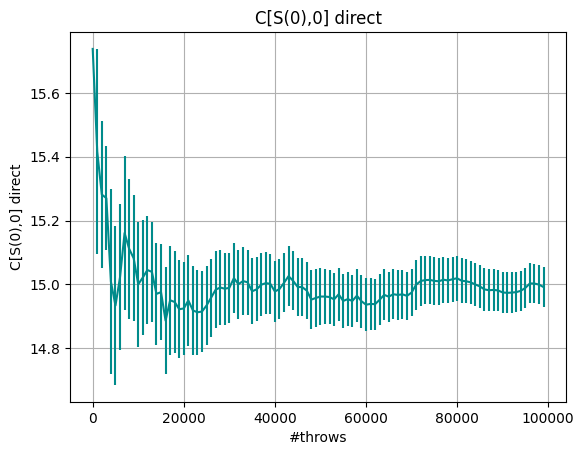

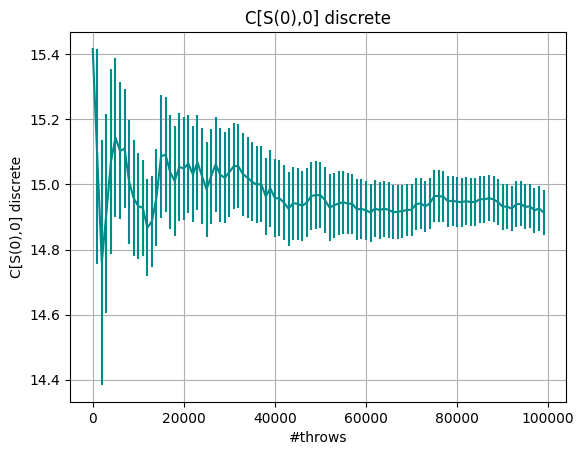

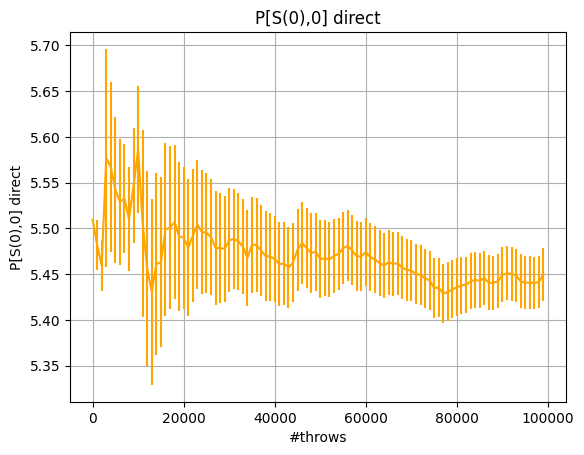

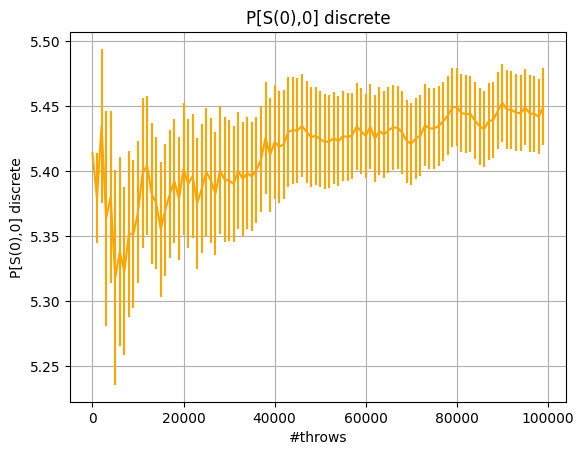

In [1]:
import matplotlib.pyplot as plt
import numpy as np

def plot(filename, title, color):
    # Load data from file
    x, f, error = np.loadtxt(filename, usecols=(0, 1, 2), delimiter=' ', unpack=True)
    # Plot data with error bars
    plt.errorbar(x, f, yerr=error, color = color )
    plt.xlabel('#throws')
    plt.ylabel(title)
    plt.title(title)
    plt.grid(True)
    plt.show()
    
# Plot direct sampling data for call option
plot("Es03.1/call.txt", "C[S(0),0] direct", 'darkcyan')

# Plot discrete sampling data for call option
plot("Es03.1/callstep.txt", "C[S(0),0] discrete", 'darkcyan')

# Plot direct sampling data for put option
plot("Es03.1/put.txt", "P[S(0),0] direct", 'orange')

# Plot discrete sampling data for put option
plot("Es03.1/putstep.txt", "P[S(0),0] discrete", 'orange')


I risultati ottenuti con tecniche Monte Carlo si possono confrontare con il valore ricavato dall'espressione analitica per il prezzo delle azioni europee del modello Black-Scholes.

In [2]:
import scipy
from scipy.special import erf
from numpy import exp
from numpy.lib.scimath import log, sqrt

# Parameters used in the Black-Scholes model
S0 = 100.      # Initial asset price
K = 100.       # Strike price
T = 1.         # Time to maturity
r = 0.1        # Risk-free interest rate
sigma = 0.25   # Asset volatility

# Cumulative distribution function of the standard normal distribution
def N(x):
    return 0.5 * (1. + erf(x / sqrt(2.)))

# Analytical calculation of European call and put option prices
def black_scholes(S0, K, T, r, sigma):
    d1 = 1. / (sigma * sqrt(T)) * (log(S0 / K) + (r + sigma**2 / 2.) * T)
    d2 = d1 - sigma * sqrt(T)

    # Theoretical price of the call option
    C = S0 * N(d1) - K * exp(-r * T) * N(d2)

    # Theoretical price of the put option
    P = S0 * (N(d1) - 1.) - K * exp(-r * T) * (N(d2) - 1.)

    return C, P

call, put = black_scholes(S0, K, T, r, sigma)

print(" == BLACK-SCHOLES ==")
print("call: ", call)
print("put: ", put)

 == BLACK-SCHOLES ==
call:  14.975790778311286
put:  5.4595325819072364


Osservando i grafici si nota che le stime Monte Carlo convergono ai valori teorici ottenuti dalla formula di Black-Scholes, sia nel caso del campionamento diretto di $S(T)$ sia nel caso della simulazione discretizzata del processo.
I due metodi utilizzati nell'esercizio sono compatibili, poiché la discretizzazione utilizzata non introduce un’approssimazione, ma applica la soluzione esatta del GBM su ciascun intervallo temporale.